## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

## Load the dataset + small sanity check

In [11]:
from prepare_dataset import PairedCIFAR10

In [12]:
train_dataset = PairedCIFAR10("train")
val_dataset = PairedCIFAR10("val")
test_dataset = PairedCIFAR10("test")

In [13]:
print(f"Train dataset: {len(train_dataset)}")
print(f"Validation dataset: {len(val_dataset)}")
print(f"Test dataset: {len(test_dataset)}")

Train dataset: 45000
Validation dataset: 5000
Test dataset: 10000


In [14]:
img, cond, lbl = train_dataset[0]

print(f"Image shape: {img.shape}")
print(f"Condition shape: {cond.shape}")
print(f"Label: {lbl}")
print(f"Condition vector: {cond}")

Image shape: torch.Size([3, 32, 32])
Condition shape: torch.Size([16])
Label: 1
Condition vector: tensor([13.1364, 11.6294, 11.1767, 20.8126, 12.1399, 11.0252, 13.0206, 20.5694,
         0.5019,  0.4321,  0.3483,  0.2652, -0.3682,  1.0011, -1.8635,  1.3442])


## Combine conditions for further analysis

In [15]:
train_cond = torch.stack([
    train_dataset[i][1]
    for i in range(len(train_dataset))
])

val_cond = torch.stack([
    val_dataset[i][1]
    for i in range(len(val_dataset))
])

print(train_cond.shape)
print(val_cond.shape)

torch.Size([45000, 16])
torch.Size([5000, 16])


In [16]:
train_cond_np = train_cond.numpy()
val_cond_np = val_cond.numpy()

## Per-feature analysis

In [17]:
stats = pd.DataFrame({
    "mean": train_cond_np.mean(axis=0),
    "std": train_cond_np.std(axis=0),
    "min": train_cond_np.min(axis=0),
    "max": train_cond_np.max(axis=0),
})

In [18]:
stats.index = [f"feature_{i}" for i in range(16)]
print(stats)

                    mean       std       min        max
feature_0   1.658992e+01  6.649331  0.004356  32.000000
feature_1   1.552499e+01  4.476121  0.160399  31.877398
feature_2   1.458326e+01  4.047385  1.069776  31.944580
feature_3   1.482755e+01  5.331635  0.023597  32.000000
feature_4   1.547271e+01  5.097522  0.047647  31.985294
feature_5   1.530247e+01  3.837391  0.264178  32.000000
feature_6   1.530288e+01  3.859938  1.056590  31.783165
feature_7   1.544756e+01  5.074954  0.000000  31.998039
feature_8   4.912369e-01  0.128299  0.009992   0.988944
feature_9   4.819507e-01  0.125664  0.013840   0.988928
feature_10  4.463568e-01  0.153138  0.012580   0.988434
feature_11  1.961784e-01  0.060102  0.016540   0.451169
feature_12  1.191828e-08  0.999987 -3.149021   3.404423
feature_13  1.388921e-08  0.999986 -3.722519   4.550948
feature_14  1.760324e-09  0.999983 -4.120705   4.216352
feature_15  8.773804e-09  0.999985 -5.173225   5.623483


## Plot and compare the distributions

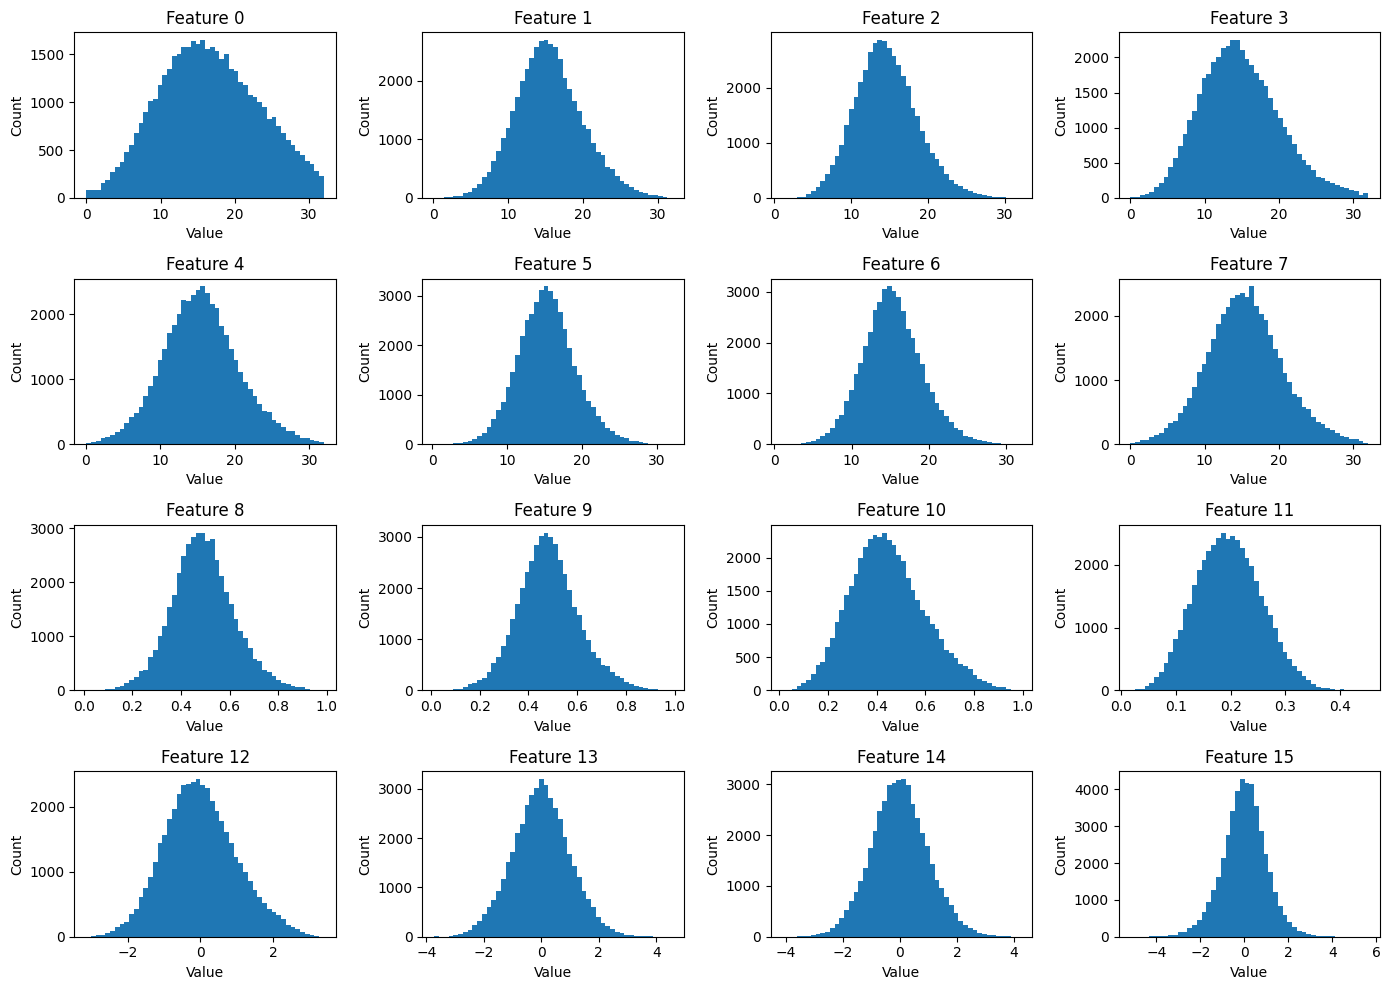

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))

for i, ax in enumerate(axes.flat):
    ax.hist(train_cond_np[:, i], bins=50)
    ax.set_title(f"Feature {i}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Train/Val distribution comparison

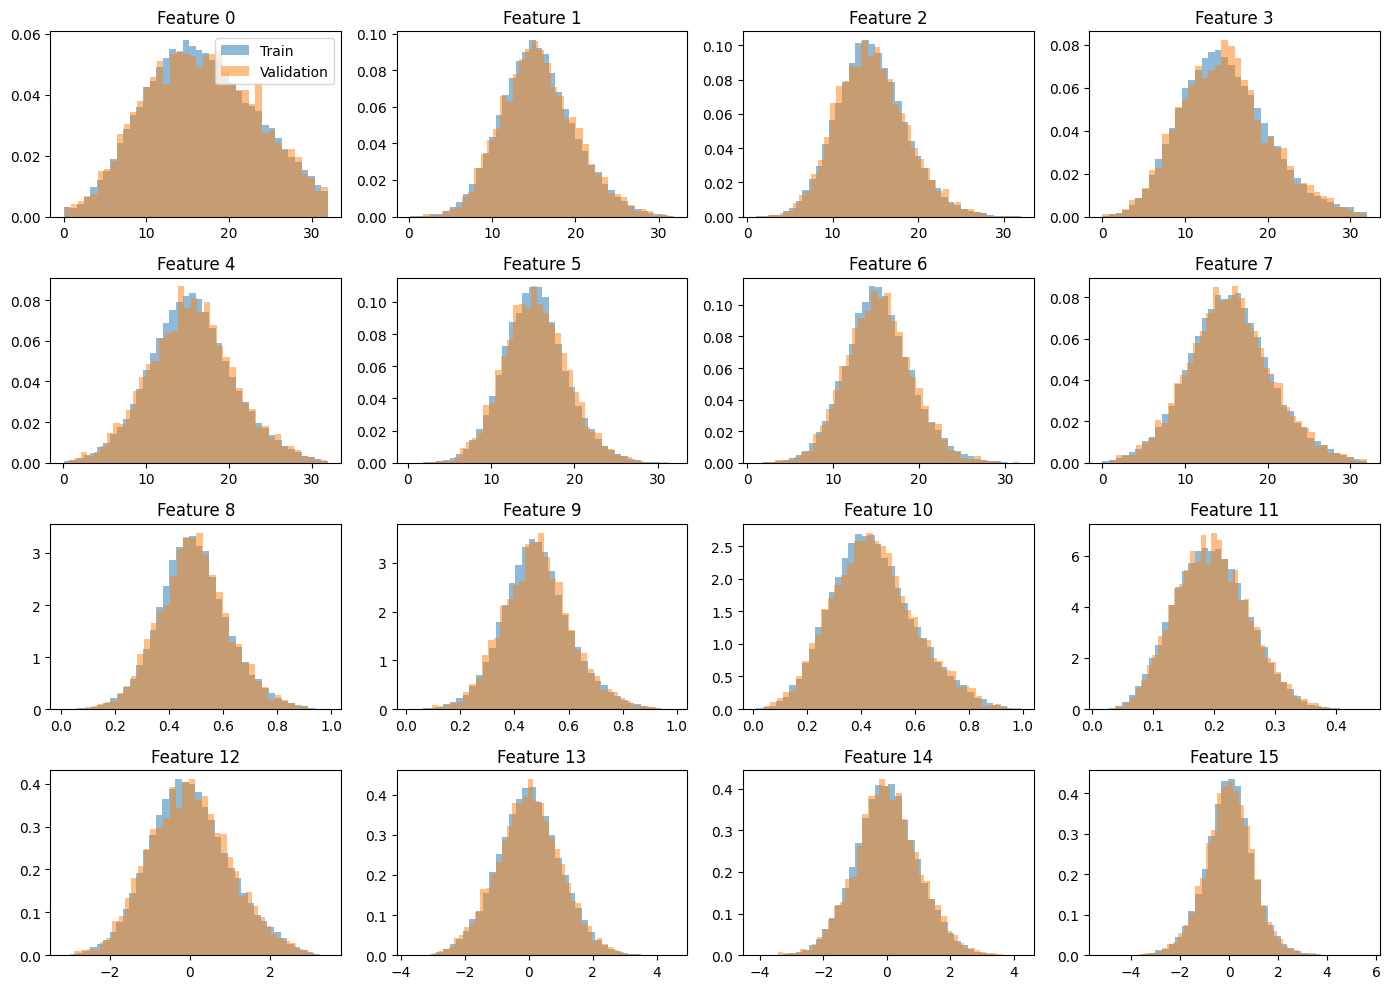

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))

for i, ax in enumerate(axes.flat):
    ax.hist(
        train_cond_np[:, i],
        bins=40,
        alpha=0.5,
        density=True,
        label="Train"
    )

    ax.hist(
        val_cond_np[:, i],
        bins=40,
        alpha=0.5,
        density=True,
        label="Validation"
    )

    ax.set_title(f"Feature {i}")

axes[0, 0].legend()

plt.tight_layout()
plt.show()

## Checking feature correlation

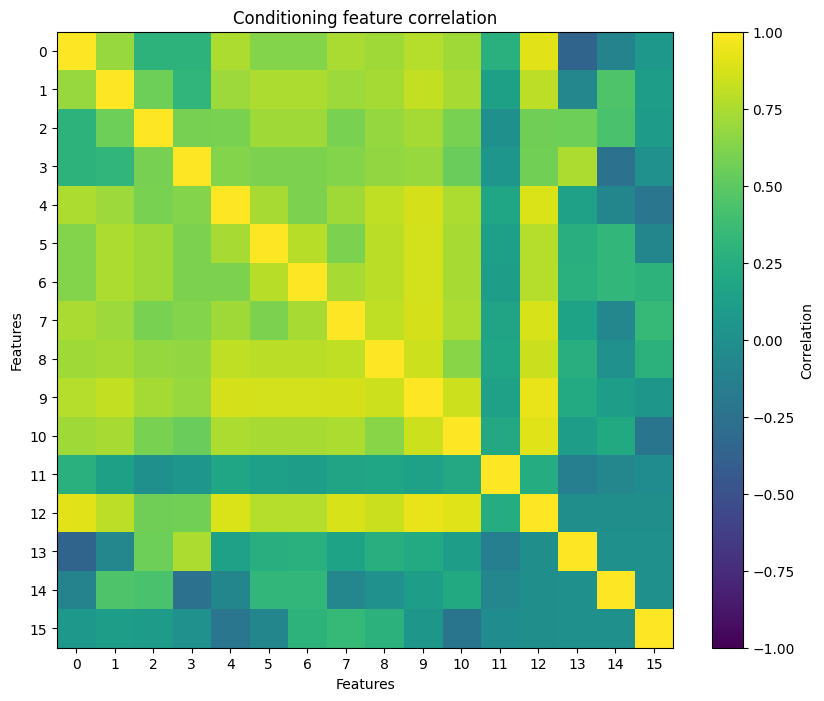

In [21]:
corr = np.corrcoef(train_cond_np, rowvar=False)

plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")


plt.xticks(range(16), range(16))
plt.yticks(range(16), range(16))

plt.xlabel("Features")
plt.ylabel("Features")
plt.title("Conditioning feature correlation")

plt.show()

## Condition analysis by class

In [22]:
train_labels = np.array([
    int(train_dataset[i][2])
    for i in range(len(train_dataset))
])

In [23]:
class_means = []

class_number = int(train_labels.max(axis=0))

for label in range(class_number):
    class_cond = train_cond_np[train_labels == label]
    class_means.append(class_cond.mean(axis=0))

class_means = np.array(class_means)

In [24]:
class_means.shape

(9, 16)

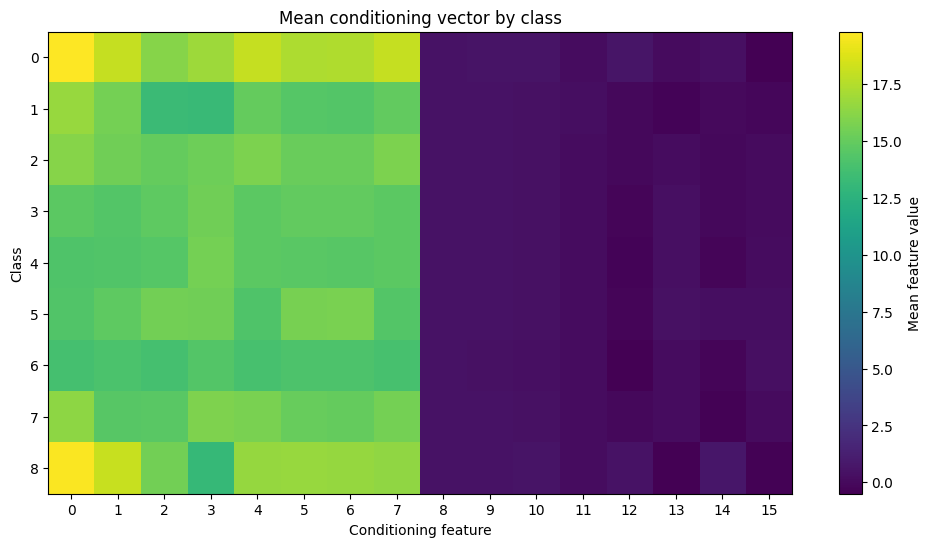

In [26]:
plt.figure(figsize=(12, 6))

plt.imshow(class_means, aspect="auto")
plt.colorbar(label="Mean feature value")

plt.xlabel("Conditioning feature")
plt.ylabel("Class")

plt.xticks(range(16))
plt.yticks(range(9))
plt.title("Mean conditioning vector by class")

plt.show()

## Conclusion